# import data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
download_loc = '/Users/gvv/Downloads/'
dpi = 300
print('Ready')

Ready


In [2]:
# import data 
df_micro = pd.read_csv('results_3_30.csv')
df_micro

# change times to seconds 
cols_to_change = ['heap_adjlist','heap_adjmatrix','heap_edgelist',
                  'heap_forwardstar','bucket_adjlist','bucket_adjmatrix',
                  'bucket_edgelist','bucket_forwardstar']

df = df_micro.copy()
df[cols_to_change] = df[cols_to_change] / 1000000.0
df


,size,nodes,heap_adjlist,heap_adjmatrix,heap_edgelist,heap_forwardstar,bucket_adjlist,bucket_adjmatrix,bucket_edgelist,bucket_forwardstar
0,3,9,0.000114,0.000117,0.000076,0.000076,0.000216,0.000227,0.000188,0.000186
1,4,16,0.000298,0.000397,0.000249,0.000214,0.000671,0.000808,0.000600,0.000572
2,5,25,0.000736,0.000894,0.000601,0.000448,0.001355,0.001474,0.001270,0.000694
3,6,36,0.001466,0.002091,0.001296,0.000501,0.001891,0.002518,0.001770,0.001290
4,7,49,0.001991,0.002935,0.002137,0.001260,0.002596,0.003441,0.002649,0.002057
5,8,64,0.002297,0.004210,0.002935,0.001555,0.003351,0.004940,0.003844,0.002661
6,9,81,0.003000,0.006013,0.004454,0.002052,0.004454,0.007252,0.005909,0.003814
7,10,100,0.004058,0.009545,0.007429,0.002999,0.006696,0.012121,0.009888,0.005810
8,11,121,0.006147,0.015872,0.012540,0.004577,0.009901,0.019464,0.015829,0.008598
9,12,144,0.008750,0.025014,0.019761,0.006504,0.014001,0.030065,0.024444,0.012084


# plot times 

## individual plots 

In [3]:
shall_we_savefig = False

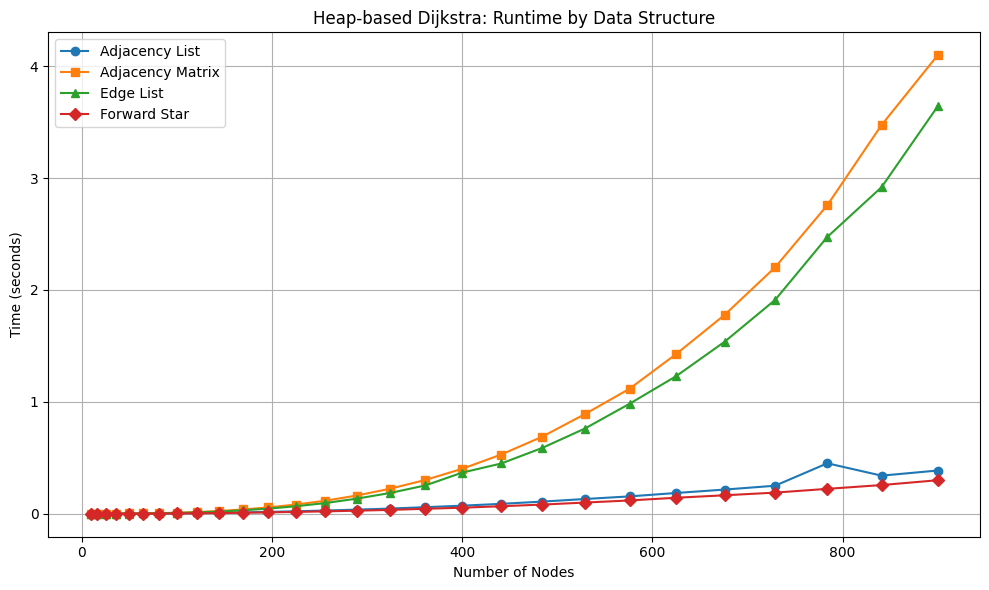

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['nodes'], df['heap_adjlist'], marker='o', label='Adjacency List')
ax.plot(df['nodes'], df['heap_adjmatrix'], marker='s', label='Adjacency Matrix')
ax.plot(df['nodes'], df['heap_edgelist'], marker='^', label='Edge List')
ax.plot(df['nodes'], df['heap_forwardstar'], marker='D', label='Forward Star')

ax.set_xlabel('Number of Nodes')
ax.set_ylabel('Time (seconds)')
ax.set_title('Heap-based Dijkstra: Runtime by Data Structure')
ax.legend()
ax.grid(True)

plt.tight_layout()
if shall_we_savefig:
    plt.savefig(download_loc + 'dijkstra_heap_runtime.png', dpi=dpi)
plt.show()

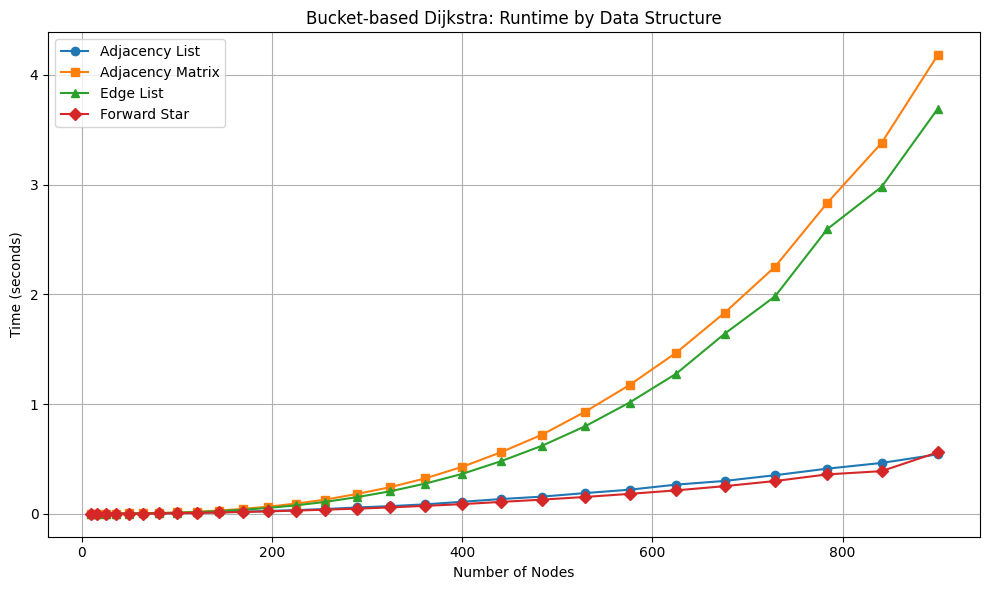

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['nodes'], df['bucket_adjlist'], marker='o', label='Adjacency List')
ax.plot(df['nodes'], df['bucket_adjmatrix'], marker='s', label='Adjacency Matrix')
ax.plot(df['nodes'], df['bucket_edgelist'], marker='^', label='Edge List')
ax.plot(df['nodes'], df['bucket_forwardstar'], marker='D', label='Forward Star')

ax.set_xlabel('Number of Nodes')
ax.set_ylabel('Time (seconds)')
ax.set_title('Bucket-based Dijkstra: Runtime by Data Structure')
ax.legend()
ax.grid(True)

plt.tight_layout()
if shall_we_savefig:
    plt.savefig(download_loc + 'dijkstra_bucket_runtime.png', dpi=dpi)
plt.show()

## paired plots 

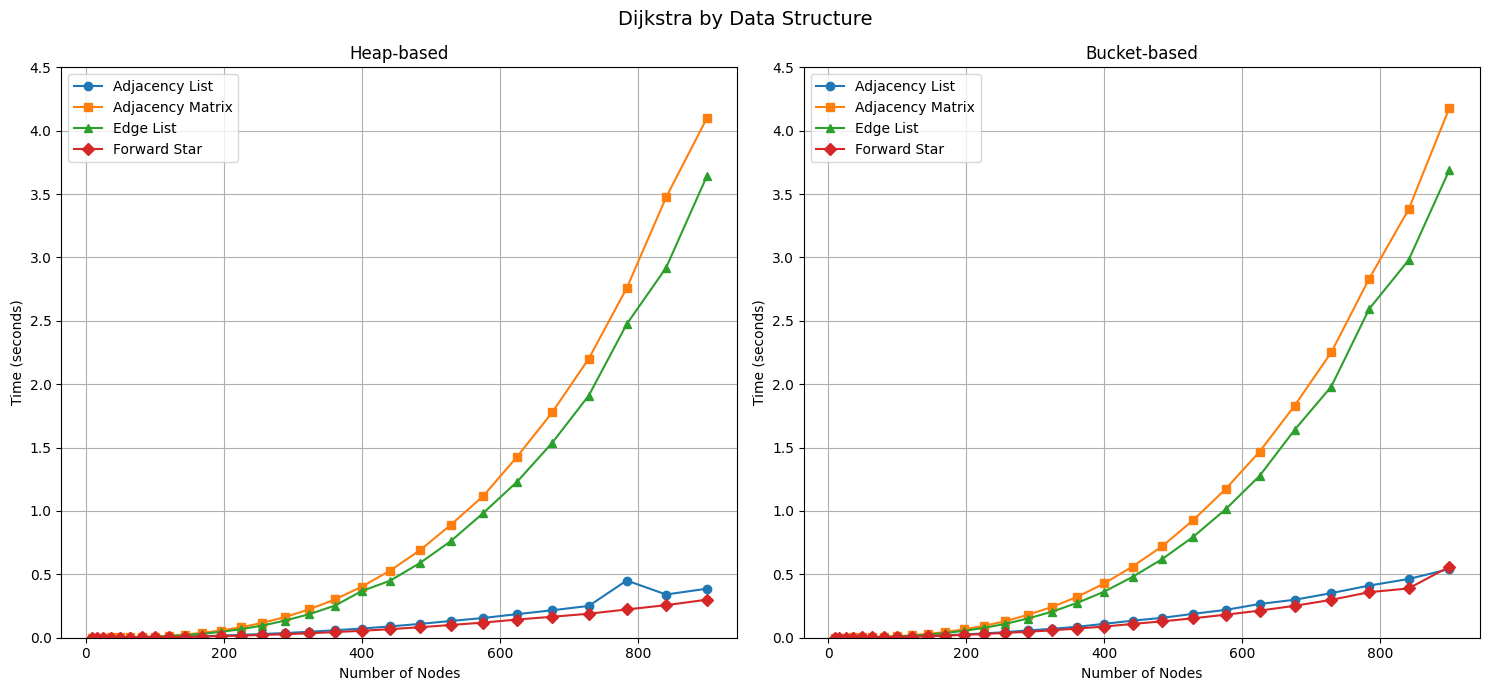

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

ax[0].plot(df['nodes'], df['heap_adjlist'], marker='o', label='Adjacency List')
ax[0].plot(df['nodes'], df['heap_adjmatrix'], marker='s', label='Adjacency Matrix')
ax[0].plot(df['nodes'], df['heap_edgelist'], marker='^', label='Edge List')
ax[0].plot(df['nodes'], df['heap_forwardstar'], marker='D', label='Forward Star')

ax[0].set_xlabel('Number of Nodes')
ax[0].set_ylabel('Time (seconds)')
ax[0].set_title('Heap-based')
ax[0].set_ylim(0, 4.5)
ax[0].legend()
ax[0].grid(True)

ax[1].plot(df['nodes'], df['bucket_adjlist'], marker='o', label='Adjacency List')
ax[1].plot(df['nodes'], df['bucket_adjmatrix'], marker='s', label='Adjacency Matrix')
ax[1].plot(df['nodes'], df['bucket_edgelist'], marker='^', label='Edge List')
ax[1].plot(df['nodes'], df['bucket_forwardstar'], marker='D', label='Forward Star')

ax[1].set_xlabel('Number of Nodes')
ax[1].set_ylabel('Time (seconds)')
ax[1].set_title('Bucket-based')
ax[1].set_ylim(0, 4.5)
ax[1].legend()
ax[1].grid(True)

fig.suptitle('Dijkstra by Data Structure', fontsize=14)

plt.tight_layout()
if shall_we_savefig:
    plt.savefig(download_loc + 'dijkstra_comparison_runtime.png', dpi=dpi)
plt.show()

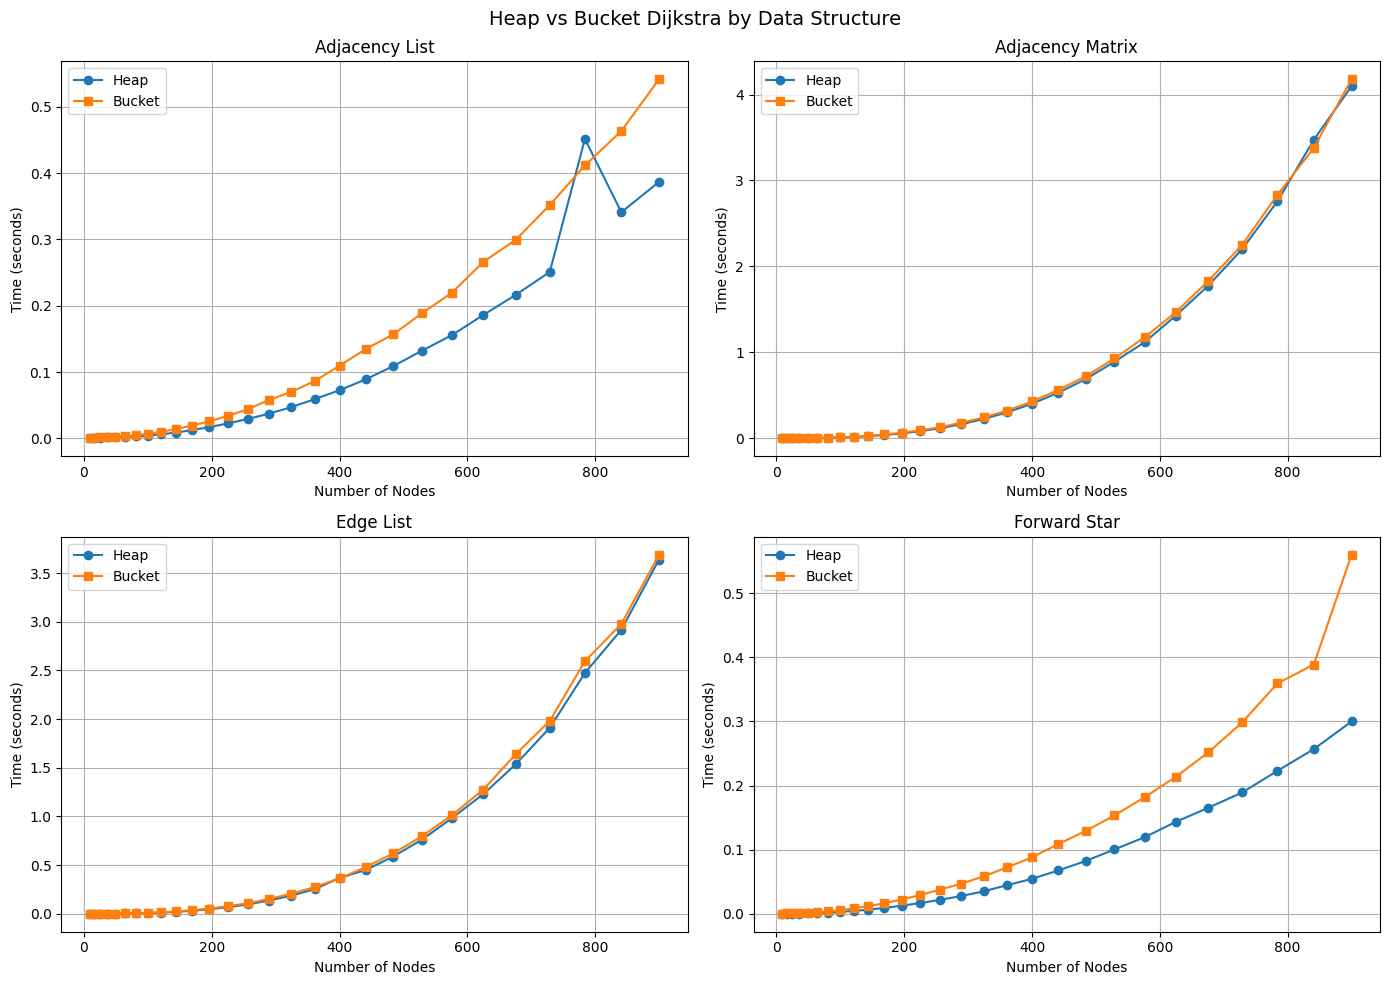

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

structures = [
    ('adjlist',     'Adjacency List'),
    ('adjmatrix',   'Adjacency Matrix'),
    ('edgelist',    'Edge List'),
    ('forwardstar', 'Forward Star'),
]

for ax, (key, title) in zip(axes.flatten(), structures):
    ax.plot(df['nodes'], df[f'heap_{key}'],   marker='o', label='Heap')
    ax.plot(df['nodes'], df[f'bucket_{key}'], marker='s', label='Bucket')
    ax.set_xlabel('Number of Nodes')
    ax.set_ylabel('Time (seconds)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

fig.suptitle('Heap vs Bucket Dijkstra by Data Structure', fontsize=14)
plt.tight_layout()
if shall_we_savefig:
    plt.savefig(download_loc + 'dijkstra_heap_bucket_comparison_runtime.png', dpi=dpi)
plt.show()

# Compare Python to C++

well that embarrassed me 😔

In [8]:
import networkx as nx
import time

def run_networkx_dijkstra(size, max_weight=10, seed=420):
    import random
    random.seed(seed)
    
    # build the grid graph
    G = nx.grid_2d_graph(size, size)
    
    # assign random weights
    for u, v in G.edges():
        G[u][v]['weight'] = random.randint(1, max_weight)
    
    # relabel nodes from tuples to ints to match your cpp implementation
    G = nx.convert_node_labels_to_integers(G)
    
    # time only the dijkstra part
    start = time.time()
    for node in G.nodes():
        nx.single_source_dijkstra_path_length(G, node, weight='weight')
    end = time.time()
    
    return end - start

# run for same sizes as your cpp benchmark
nx_times = []
for size in range(3, 31):  # adjust to match your lowerBound and upperBound
    t = run_networkx_dijkstra(size)
    nx_times.append(t)
    print(f"Size {size}x{size}: {t:.4f} seconds")

df['networkx'] = nx_times

Size 3x3: 0.0001 seconds
Size 4x4: 0.0001 seconds
Size 5x5: 0.0003 seconds
Size 6x6: 0.0006 seconds
Size 7x7: 0.0011 seconds
Size 8x8: 0.0019 seconds
Size 9x9: 0.0032 seconds
Size 10x10: 0.0047 seconds
Size 11x11: 0.0070 seconds
Size 12x12: 0.0100 seconds
Size 13x13: 0.0140 seconds
Size 14x14: 0.0188 seconds
Size 15x15: 0.0252 seconds
Size 16x16: 0.0333 seconds
Size 17x17: 0.0427 seconds
Size 18x18: 0.0543 seconds
Size 19x19: 0.0690 seconds
Size 20x20: 0.0846 seconds
Size 21x21: 0.1072 seconds
Size 22x22: 0.1280 seconds
Size 23x23: 0.1531 seconds
Size 24x24: 0.1819 seconds
Size 25x25: 0.2142 seconds
Size 26x26: 0.2501 seconds
Size 27x27: 0.2965 seconds
Size 28x28: 0.3481 seconds
Size 29x29: 0.3979 seconds
Size 30x30: 0.4647 seconds


# Visual summary supplementals 

this is just stuff for talking about the data structures using some basic network that is easily visible. 

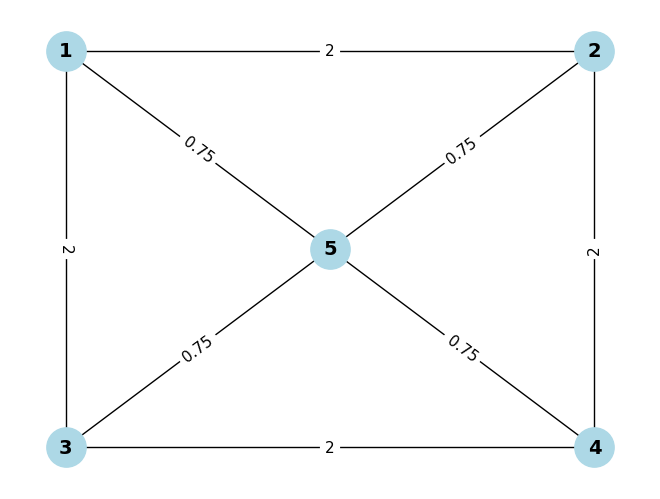

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

edges = [
    (1, 2, 2),
    (1, 3, 2), 
    (3, 4, 2), 
    (4, 2, 2), 
    (5, 1, 0.75),
    (5, 2, 0.75),
    (5, 3, 0.75),
    (5, 4, 0.75),
]

G.add_weighted_edges_from(edges)

# fixed positions so it looks like a square with a center node
pos = {
    1: (0, 1),    # top left
    2: (1, 1),    # top right
    3: (0, 0),    # bottom left
    4: (1, 0),    # bottom right
    5: (0.5, 0.5) # center
}

edge_labels = {(u, v): w for u, v, w in edges}

nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=800, font_size=14, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11)

# plt.title("Sample network")
plt.axis('off')
# plt.savefig(download_loc + 'sample_network.png', dpi=dpi)
plt.show()